# SBI 2026 : Gaussian process

The goal of PhD thesis is to find an alternative to the Maximum LIkelihood Estimation (MLE). I'd like to know how SBI can be used in this purpose.

**Workflow:**

* Simulator and prior : OK (see github)
* Choose component for simulation based inference
    * Data representation : 1D time 1D space => grid of values / images (could be a graph)
    * inference algorithm : NLE in first place (might have a lot of observation)
    * inference network : CNN
* Execute simulation based inference
    * Simulate dataset
    * train neural network
    * perform inference
* Diagnostic inference
* Analyze posterior

In [1]:
import matplotlib.pyplot as plt

import numpy as np

import random
from tqdm import tqdm
import time
import os
import joblib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [3]:
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from scipy.optimize import minimize
import scipy.linalg as linalg
from scipy.special import gamma, kv

In [4]:
import gstlearn as gl
import gstlearn.plot as gp
import gstlearn.document as gdoc
gdoc.setNoScroll()

<IPython.core.display.Javascript object>

In [5]:
import sbi

from sbi.inference import NPE, NLE, SNPE
from sbi.analysis import pairplot
from sbi.utils import BoxUniform 

from sbi.neural_nets import posterior_nn
from sbi.neural_nets.embedding_nets import CNNEmbedding

In [6]:
from utils import corner_plot

## Variables

In [7]:
space_size = 30
time_size = 30
deepset_size = 1
missing_ratio = 1/2

train_size = 4000
test_size = 1000

## Utils

In [8]:
def add_missing_mask(batch, missing_ratio):
    nb_missing = int(space_size*missing_ratio)
    missings = np.sort(np.random.permutation(space_size)[:nb_missing])
    batch[:,:,:,missings] = 0
    mask = np.zeros_like(batch)
    mask[:,:,:,missings] = 1
    return np.concatenate([batch, mask], axis=1) 

In [9]:
# Remark : advection (first param) had lowerbound and upperbound set to 0 => bug in build posterior

def create_prior():

    lower_bound = torch.as_tensor([-3, 0.05, 0.05, 0.1])
    upper_bound = torch.as_tensor([3, 0.25, 0.25, 1.])
    prior = BoxUniform(low=lower_bound, high=upper_bound)

    return prior

In [10]:
def simulate_matern_grid(theta, time_size=30, space_size=30, deepset_size=1):
    
    batch = []
    
    for th in theta :
        
        adv, range_time, range_space, std = int(th[0]), th[1], th[2], th[3]
        # adv, range_time, range_space, std = 0, th[0], th[1], th[2]
        
                
        model = gl.Model.createFromParam(gl.ECov.MATERN, ranges = [range_time,range_space], param = 1, sill = std**2, flagRange=False)

        shape_adv = abs(adv)+1

        grid = gl.DbGrid.create(
            nx = [time_size,space_size  + time_size*shape_adv],    
            dx = [1./time_size,1./space_size]
        )

        mesh = gl.MeshETurbo(grid)

        pop = gl.PrecisionOpMatrix(mesh, model.getCovAniso(0))
        
        for i in range(deepset_size):

            res = pop.simulateOne()
            res = res.reshape((time_size,space_size + time_size*shape_adv), order='F')

            t, s = np.meshgrid(np.arange(time_size), np.arange(space_size), indexing='ij')
            offset = t.copy() * abs(adv)
            s = s + offset


            if adv >= 0 :
                res = res[t,s]
            else :
                res = np.fliplr(res)
                res = res[t,s]
                res = np.fliplr(res)

            batch.append(res)

    batch = np.stack(batch)
    batch = np.expand_dims(batch,1)
    
    if missing_ratio > 0:
        batch = add_missing_mask(batch, missing_ratio)
    
    return torch.from_numpy(batch).to(torch.float32)

## Inference

### NPE

In [11]:
prior = create_prior()

In [12]:
theta = prior.sample((train_size,))
theta.shape

torch.Size([4000, 4])

In [13]:
x = simulate_matern_grid(theta)
x.shape

torch.Size([4000, 2, 30, 30])

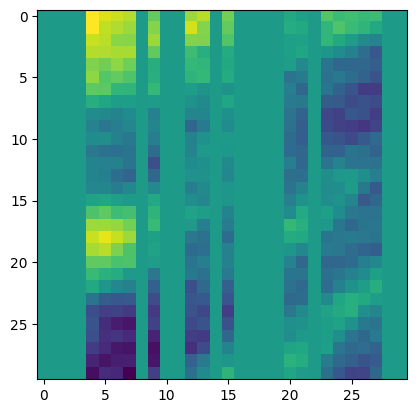

In [14]:
# Remark : The advection over time create a structure in the image

plt.imshow(x[1,0])

In [15]:
# Remark : 2D CNN

# embedding_net = CNNEmbedding(
#     input_shape=(time_size,space_size,),
#     in_channels=2,
#     output_dim=20,
# )

class CustomCNN(nn.Module):
    def __init__(self, in_channels=2, hidden=32, out_dim=20):
        super().__init__()
        self.conv2d = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=hidden, kernel_size=5, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden, out_channels=hidden, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
        )
        self.pool2d = nn.AdaptiveAvgPool2d(1) 

        self.dense = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)  
        )
        
    def forward(self, x):
        B,C,T,S = x.shape
        summary = self.conv2d(x)

        summary = self.pool2d(summary).view(B, -1)
        # out = self.dense(summary)
        # return out
        return summary

embedding_net = CustomCNN()

torch.any(torch.isnan(x)), torch.any(torch.isnan(embedding_net(x)))

(tensor(False), tensor(False))

In [16]:
# Remark : A bug here with "structured"

density_estimator = posterior_nn(model="maf", embedding_net=embedding_net, z_score_x="none")
# density_estimator = posterior_nn(model="maf", embedding_net=embedding_net, z_score_x="structured")

In [17]:
npe_cnn = NPE(prior=prior, density_estimator=density_estimator) 

In [18]:
npe_cnn.append_simulations(theta,x).train(max_num_epochs=1000)

 Neural network successfully converged after 272 epochs.

NFlowsFlow(
  (net): Flow(
    (_transform): CompositeTransform(
      (_transforms): ModuleList(
        (0): PointwiseAffineTransform()
        (1): MaskedAffineAutoregressiveTransform(
          (autoregressive_net): MADE(
            (initial_layer): MaskedLinear(in_features=4, out_features=50, bias=True)
            (context_layer): Linear(in_features=32, out_features=50, bias=True)
            (blocks): ModuleList(
              (0-1): 2 x MaskedFeedforwardBlock(
                (linear): MaskedLinear(in_features=50, out_features=50, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (final_layer): MaskedLinear(in_features=50, out_features=8, bias=True)
          )
        )
        (2): RandomPermutation()
        (3): MaskedAffineAutoregressiveTransform(
          (autoregressive_net): MADE(
            (initial_layer): MaskedLinear(in_features=4, out_features=50, bias=True)
            (context_layer): Linear(in_featur

In [19]:
posterior = npe_cnn.build_posterior() 

In [20]:
theta_test = prior.sample((test_size,))
theta_test[:,0] = torch.round(theta_test[:,0])
x_test = simulate_matern_grid(theta_test) 

limits = [[-3,3],[0.05,0.25],[0.05,0.25],[.1,1.]]
param_labels = ['advection', 'range time', 'range space', 'std']

  0%|          | 0/10000 [00:00<?, ?it/s]

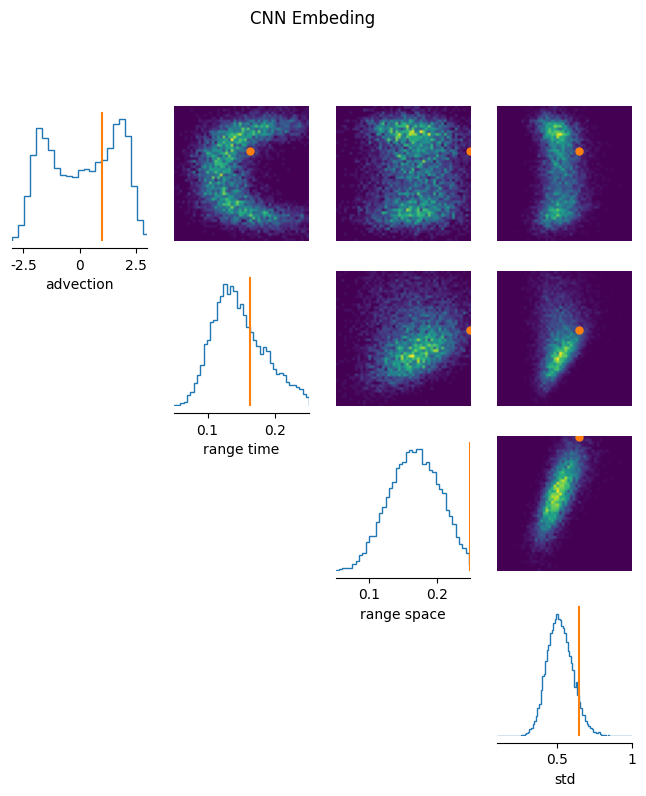

In [21]:
k = 0

samples_cnn = posterior.sample((10_000,), x=x_test[k])

fig, axes = pairplot(
    samples_cnn,
    limits=limits,
    labels=param_labels,
    figsize=(8, 8),
    points=theta_test[k],
)
plt.suptitle("CNN Embeding", y=1.02)
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'reconstruct\ntensor([1.3608, 0.1835, 0.2065, 0.5525])')

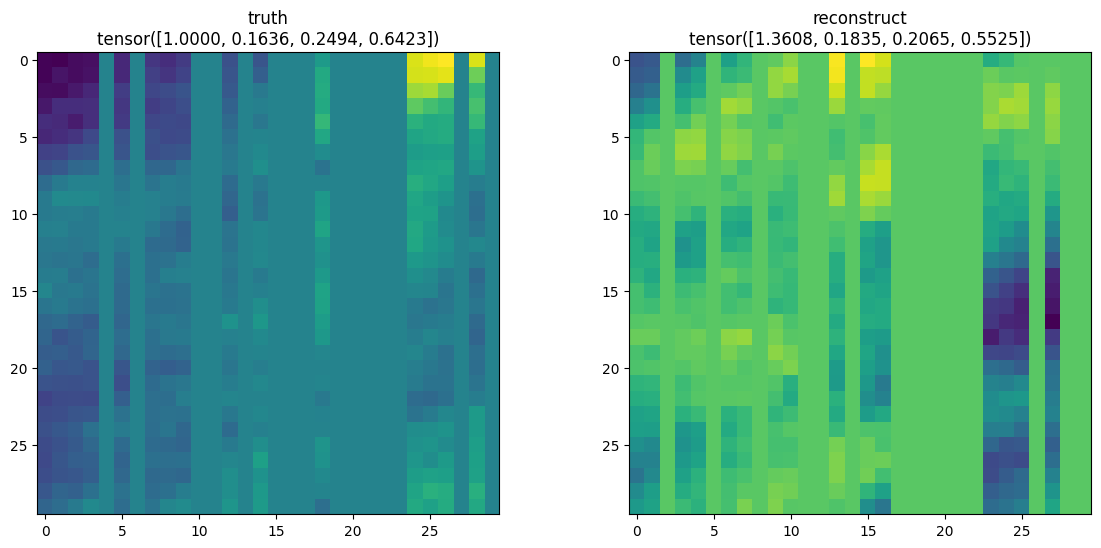

In [22]:
k_ = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(x_test[k_,0])
axes[0].set_title(f"truth\n{theta_test[k_]}")

s = posterior.sample((10_000,), x=x_test[k_])
s = s[1] # torch.mean(s,dim=0)
axes[1].imshow(simulate_matern_grid(s.unsqueeze(dim=0))[0,0])
axes[1].set_title(f"reconstruct\n{s}")

In [23]:
res = []
for i in range(test_size):
    res.append(abs(theta_test[i]-torch.mean(posterior.sample((10_000,), x=x_test[i],show_progress_bars=False),dim=0)))
res = torch.stack(res)

In [24]:
torch.mean(res,dim=0)

tensor([1.5059, 0.0427, 0.0335, 0.0798])

### SNPE